# EPSP ratio comparison with Sjostrom et al. 2001 dataset dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Sjostrom et al. 2001"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
13,sjs01_01,L5TTPC,L5TTPC,VC,rat,P12 - P21,0.1,10,1,50,10,0.963900,0.051000,7,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.134933
14,sjs01_02,L5TTPC,L5TTPC,VC,rat,P12 - P21,10.0,10,5,15,10,1.152300,0.102100,6,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.250093
15,sjs01_03,L5TTPC,L5TTPC,VC,rat,P12 - P21,20.0,10,5,15,10,1.305400,0.139100,3,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.240928
16,sjs01_04,L5TTPC,L5TTPC,VC,rat,P12 - P21,40.0,10,5,15,10,1.539500,0.112700,6,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.276057
17,sjs01_05,L5TTPC,L5TTPC,VC,rat,P12 - P21,50.0,10,5,15,10,1.558900,0.269400,6,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.659893
18,sjs01_06,L5TTPC,L5TTPC,VC,rat,P12 - P21,0.1,-10,1,50,10,0.681660,0.077140,7,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.204093
19,sjs01_07,L5TTPC,L5TTPC,VC,rat,P12 - P21,10.0,-10,5,15,10,0.563570,0.107810,3,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.186732
20,sjs01_08,L5TTPC,L5TTPC,VC,rat,P12 - P21,20.0,-10,5,15,10,0.638790,0.090160,4,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.180320
21,sjs01_09,L5TTPC,L5TTPC,VC,rat,P12 - P21,40.0,-10,5,15,10,1.500270,0.304830,5,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.681621
22,sjs01_10,L5TTPC,L5TTPC,VC,rat,P12 - P21,50.0,-10,5,15,10,1.691670,0.185887,10,Sjostrom et al. 2001,Record digitized from paper. Cao = 2.5 mM.,0.587826


In [2]:
# Load Sjostrom et al. 2001 data for high-frequency protocols
insilico_exp_hf, insilico_out_hf, insilico_hf = \
    load_insilico('data/insilico/sjostrom_2001/L5TTPC_L5TTPC.csv')

# Load data for low-frequency protocols
insilico_exp_lf, insilico_out_lf, insilico_lf = \
    load_insilico('data/insilico/sjostrom_2001/L5TTPC_L5TTPC_lowfreq.csv')

No outliers in data/insilico/sjostrom_2001/L5TTPC_L5TTPC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
903,143373,161321,50.0,-25,NaN,NaN
674,158685,154151,50.0,10,2.929187,0.496987
1624,153957,150898,20.0,10,1.108091,1.932457
1214,146330,156703,40.0,0,1.820964,2.996326
2164,144486,161496,10.0,10,2.252339,1.129784


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,10.0,-25,0.802837,0.432689,0.043269,100
1,10.0,-10,0.816155,0.365044,0.036504,100
2,10.0,0,0.898135,0.452918,0.045292,100
3,10.0,10,1.056326,0.432623,0.043262,100
4,10.0,25,0.935494,0.414690,0.041469,100
5,20.0,-25,1.205747,0.423387,0.042339,100
6,20.0,-10,1.194273,0.448569,0.044857,100
7,20.0,0,1.246211,0.447788,0.044779,100
8,20.0,10,1.251368,0.447918,0.044792,100
9,20.0,25,1.220349,0.444530,0.044453,100


No outliers in data/insilico/sjostrom_2001/L5TTPC_L5TTPC_lowfreq.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
164,136415,150486,0.1,0,1.105785,0.277184
200,140267,154486,0.1,-10,1.024627,2.016151
73,152903,136051,0.1,10,0.850868,2.886593
163,141564,153894,0.1,0,1.000551,3.578016
115,145233,144584,0.1,0,2.273083,0.932396


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,0.1,-10,0.879562,0.207803,0.020780,100
1,0.1,0,0.999239,0.343672,0.034367,100
2,0.1,10,1.083715,0.499324,0.049932,100


In [3]:
# Concatenate datasets
insilico_exp = pd.concat([insilico_exp_hf, insilico_exp_lf], verify_integrity=True, ignore_index=True)
insilico_exp.sample(5)

,pregid,postgid,frequency_train,dt_train,path,epsp_before,epsp_after,epsp_ratio,epsp_before_std,epsp_after_std,...,gmax_AMPA_before_std,spine_volume_mean,spine_volume_std,Nrrp_mean,Nrrp_std,Cpre_mean,Cpre_std,Cpost_mean,Cpost_std,risetime
2290,155791,146178,10.0,0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,3.227331,3.702634,1.147274,0.284823,0.221507,...,0.963130,0.165592,0.102049,3.714286,1.484615,0.072324,0.027457,0.007644,0.011080,1.300
2121,147705,143848,10.0,10,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,2.341966,2.103376,0.898124,0.408180,0.377673,...,0.595977,0.168690,0.057275,3.250000,0.829156,0.074363,0.011188,0.004127,0.005924,1.425
361,144555,140379,100.0,-10,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
828,141711,144539,50.0,-10,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,3.047548,5.189308,1.702781,0.285322,0.095319,...,1.615218,0.202213,0.112191,4.250000,1.785357,0.065496,0.023447,0.025672,0.040458,1.525
1320,143442,150389,40.0,-10,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,1.840002,1.419113,0.771256,0.240490,0.287439,...,1.577910,0.180989,0.114929,3.800000,1.939072,0.176522,0.130291,0.000041,0.000014,3.875


In [4]:
# Concatenate datasets
insilico = pd.concat([insilico_hf, insilico_lf], verify_integrity=True, ignore_index=True)
insilico

,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,10.0,-25,0.802837,0.432689,0.043269,100
1,10.0,-10,0.816155,0.365044,0.036504,100
2,10.0,0,0.898135,0.452918,0.045292,100
3,10.0,10,1.056326,0.432623,0.043262,100
4,10.0,25,0.935494,0.414690,0.041469,100
5,20.0,-25,1.205747,0.423387,0.042339,100
6,20.0,-10,1.194273,0.448569,0.044857,100
7,20.0,0,1.246211,0.447788,0.044779,100
8,20.0,10,1.251368,0.447918,0.044792,100
9,20.0,25,1.220349,0.444530,0.044453,100


t-test results for frequency_train = 0.100000: s = 1.679, p = 0.107
t-test results for frequency_train = 10.000000: s = -0.866, p = 0.416
t-test results for frequency_train = 20.000000: s = -0.370, p = 0.741
t-test results for frequency_train = 40.000000: s = -1.844, p = 0.109
t-test results for frequency_train = 50.000000: s = -0.878, p = 0.418


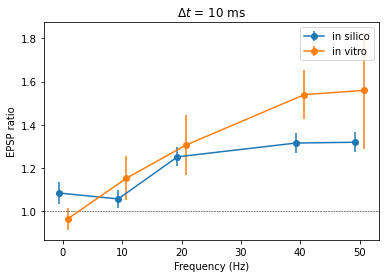

In [5]:
# Plot LTP freq
sel_invitro = invitro[invitro.dt_train==10]
sel_insilico = insilico[insilico.dt_train==10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = 10 ms');
#fig.savefig('l5_l5_ltp.svg')

t-test results for frequency_train = 0.100000: s = 2.477, p = 0.043
t-test results for frequency_train = 10.000000: s = 2.219, p = 0.132
t-test results for frequency_train = 20.000000: s = 5.516, p = 0.003
t-test results for frequency_train = 40.000000: s = -0.712, p = 0.514
t-test results for frequency_train = 50.000000: s = -2.050, p = 0.067


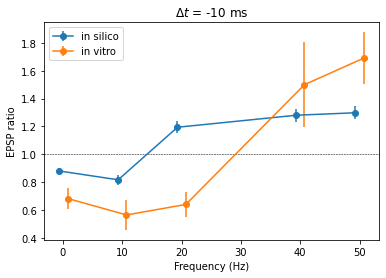

In [6]:
# Plot LTD freq
sel_invitro = invitro[invitro.dt_train==-10]
sel_insilico = insilico[insilico.dt_train==-10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = -10 ms');
#fig.savefig('l5_l5_ltd.svg')

t-test results for frequency_train = 0.100000: s = 0.622, p = 0.564
t-test results for frequency_train = 20.000000: s = 4.454, p = 0.005
t-test results for frequency_train = 40.000000: s = 6.531, p = 0.000
t-test results for frequency_train = 50.000000: s = 6.898, p = 0.000
t-test results for frequency_train = 100.000000: s = 1.291, p = 0.229


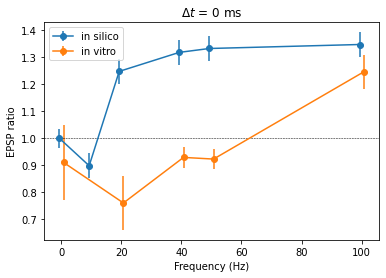

In [7]:
# Plot LTD freq
sel_invitro = invitro[invitro.dt_train==0]
sel_insilico = insilico[insilico.dt_train==0]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro')
ax.set_title(r'$\Delta t$ = 0 ms');
#fig.savefig('l5_l5_sync.svg')

t-test results for dt_train = -10.000000: s = 2.477, p = 0.043
t-test results for dt_train = 0.000000: s = 0.622, p = 0.564
t-test results for dt_train = 10.000000: s = 1.679, p = 0.107


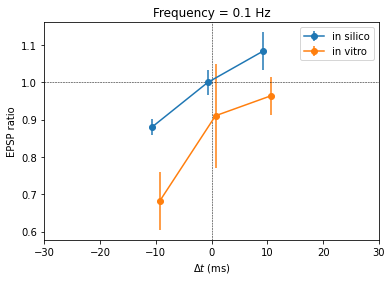

In [8]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==0.1]
sel_insilico = insilico[insilico.frequency_train==0.1]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_xlim(-30, 30)
ax.set_title('Frequency = 0.1 Hz');
#fig.savefig('l5_l5_stdp0p1.svg')

t-test results for dt_train = -10.000000: s = 2.219, p = 0.132
t-test results for dt_train = 10.000000: s = -0.866, p = 0.416


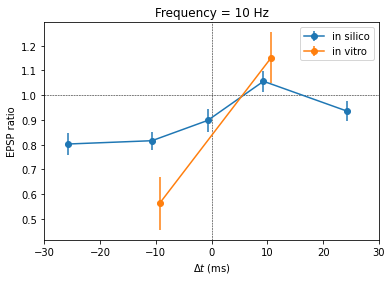

In [9]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==10]
sel_insilico = insilico[insilico.frequency_train==10]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_xlim(-30, 30)
ax.set_title('Frequency = 10 Hz');
#fig.savefig('l5_l5_stdp10.svg')

t-test results for dt_train = -25.000000: s = 6.129, p = 0.000
t-test results for dt_train = -10.000000: s = 5.516, p = 0.003
t-test results for dt_train = 0.000000: s = 4.454, p = 0.005
t-test results for dt_train = 10.000000: s = -0.370, p = 0.741
t-test results for dt_train = 25.000000: s = 3.007, p = 0.034


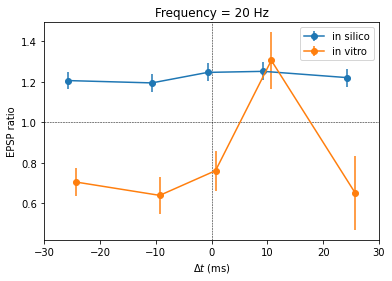

In [10]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==20]
sel_insilico = insilico[insilico.frequency_train==20]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_xlim(-30, 30)
ax.set_title('Frequency = 20 Hz');
#fig.savefig('l5_l5_stdp20.svg')

t-test results for dt_train = -10.000000: s = -0.712, p = 0.514
t-test results for dt_train = 0.000000: s = 6.531, p = 0.000
t-test results for dt_train = 10.000000: s = -1.844, p = 0.109


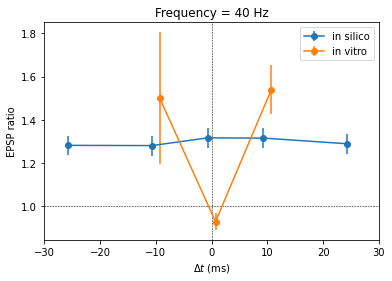

In [11]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==40]
sel_insilico = insilico[insilico.frequency_train==40]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_xlim(-30, 30)
ax.set_title('Frequency = 40 Hz');
#fig.savefig('l5_l5_stdp40.svg')

t-test results for dt_train = -10.000000: s = -2.050, p = 0.067
t-test results for dt_train = 0.000000: s = 6.898, p = 0.000
t-test results for dt_train = 10.000000: s = -0.878, p = 0.418


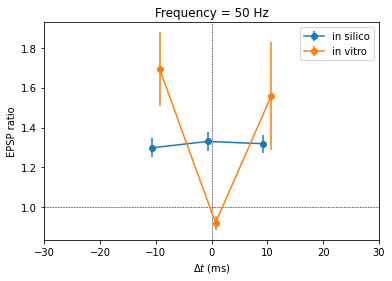

In [12]:
# Plot STDP
sel_invitro = invitro[invitro.frequency_train==50]
sel_insilico = insilico[insilico.frequency_train==50]
#print(sel_insilico)

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')
ax.set_xlim(-30, 30)
ax.set_title('Frequency = 50 Hz');
#fig.savefig('l5_l5_stdp50.svg')

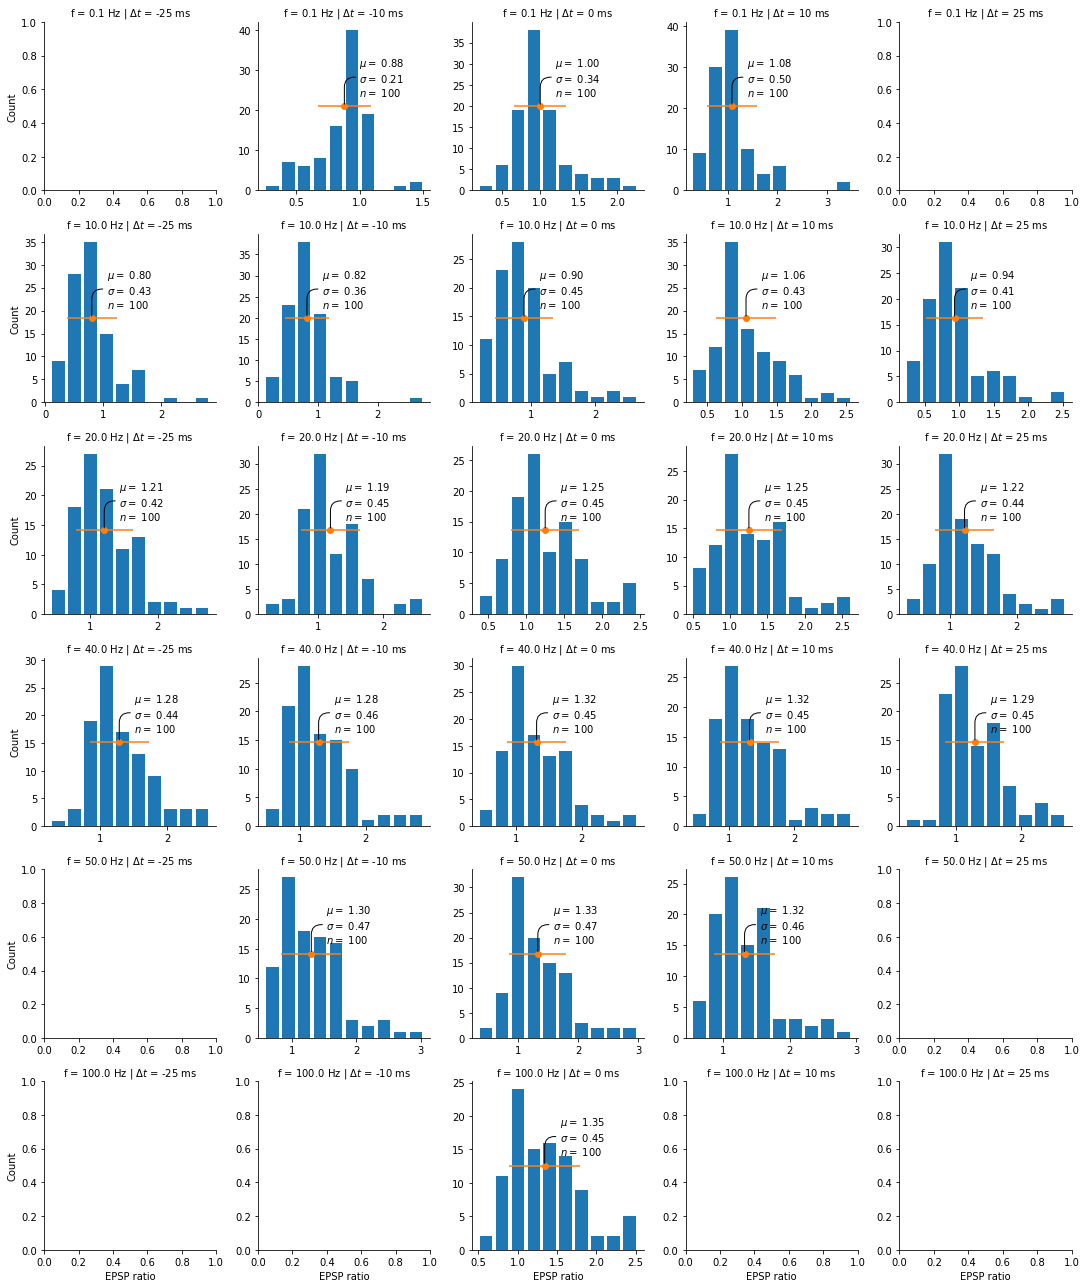

In [13]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"}).dropna()

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l5_l5_sjs01_hist.png", dpi=300)
#g.savefig("l5_l5_sjs01_hist.svg")